**Imports**

In [1]:
from eeg_framework.datasets      import *
from eeg_framework.preprocessing import *
from eeg_framework.plotting      import *
from eeg_framework.features      import *
from eeg_framework.models        import *
from eeg_framework.evaluate      import *
#from eeg_framework.utils         import *

**Load Data**

In [2]:
root_dir = "data//OpenBMI MI//"
subjects = [1]
filter_param = {"l_freq":8.0, "h_freq": 30.0, "notch_freq": 60.0}

epochs_train = load_openbmi_mi(root_dir=root_dir, split="train", subjects=subjects, concatenate=True, **filter_param)
epochs_test  = load_openbmi_mi(root_dir=root_dir, split="test",  subjects=subjects, concatenate=True, **filter_param)

Adding metadata with 3 columns
[OpenBMIMI] subject=1 session=1 split='train' | 100 epochs | 62 ch | 1000 Hz
Adding metadata with 3 columns
[OpenBMIMI] subject=1 session=2 split='train' | 100 epochs | 62 ch | 1000 Hz
Adding metadata with 3 columns
[OpenBMIMI] subject=1 session=1 split='test' | 100 epochs | 62 ch | 1000 Hz
Adding metadata with 3 columns
[OpenBMIMI] subject=1 session=2 split='test' | 100 epochs | 62 ch | 1000 Hz


In [3]:
epochs_train

<EpochsArray | 200 events (all good), -0.5 – 4 s (baseline off), ~425.9 MiB, data loaded, with metadata,
 'right': 100
 'left': 100>

**Preprocessing**

In [4]:
pipe_preprocessing = PreprocessingPipeline([
    ('crop', CAR()),
    ('rs',   Resample(100.0)),
    # ...
])

epochs_train_f = pipe_preprocessing.fit_transform(epochs_train)
epochs_test_f  = pipe_preprocessing.transform(epochs_test)

[Pipeline] fit_transform → crop
[Pipeline] fit_transform → rs
[Pipeline] applying → crop
[Pipeline] applying → rs


**Plotting**

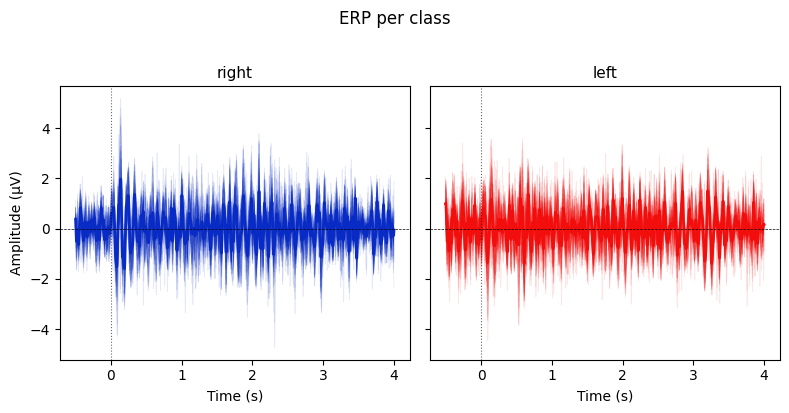

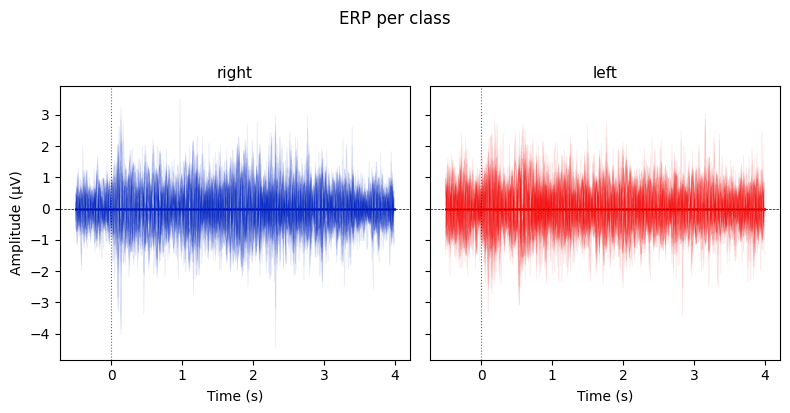

In [5]:
# ERP -------
# ERP before preprocessing
plot_erp_compare(epochs_train) 
# ERP after preprocessing
plot_erp_compare(epochs_train_f)

# Another Plot
# ...

**Features**

In [6]:
pipe_feature = FeaturePipeline([
    ('RAW', RawFeatures(flatten=False)),
    # ...
])

X_train, y_train = pipe_feature.fit_transform(epochs_train_f)
X_test, y_test = pipe_feature.transform(epochs_test_f)

[FeaturePipeline] fitting → RAW
[FeaturePipeline] extracting → RAW
[RawFeatures] shape: (200, 62, 450)
[FeaturePipeline] extracting → RAW
[RawFeatures] shape: (200, 62, 450)


**Model**

In [7]:
# EEGNet Example
eegnet_config = eegnet_params_from_epochs(epochs_train_f)
clf_model = build_eegnet(n_classes=5, compile_model=True, **eegnet_config)

history = clf_model.fit(X_train, y_train, epochs = 50, validation_split=0.2)

I0000 00:00:1779199053.731938  117370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779199053.732811  117370 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779199053.760755  117370 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779199055.326704  117370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.3438 - loss: 1.5350 - val_accuracy: 0.3500 - val_loss: 1.5862
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4437 - loss: 1.4004 - val_accuracy: 0.3500 - val_loss: 1.5617
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 1.2823 - val_accuracy: 0.3500 - val_loss: 1.5371
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5312 - loss: 1.1923 - val_accuracy: 0.3500 - val_loss: 1.5129
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6062 - loss: 1.1298 - val_accuracy: 0.3500 - val_loss: 1.4909
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5875 - loss: 1.0795 - val_accuracy: 0.3500 - val_loss: 1.4701
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5562 - loss: 1.0532 - val_accuracy: 0.3500 - val_loss: 1.4510
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5188 - loss: 1.0238 - val_accuracy: 0.3500 - val_loss: 1.4331

**Evaluation**

In [8]:
class_names = list(epochs_train.event_id.keys())
y_pred = clf_model.predict(X_test)

# Metrics
compute_metrics(y_test, y_pred, class_names=class_names)

# Other metrics and plots
# ....

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


{'accuracy': 0.56,
 'f1_macro': 0.5435211121485631,
 'f1_weighted': 0.543521112148563,
 'recall_macro': 0.56,
 'recall_weighted': 0.56,
 'cohen_kappa': 0.12,
 'confusion_matrix': array([[75, 25],
        [63, 37]]),
 'per_class': {'right': {'accuracy': 0.75,
   'f1': 0.6302521008403361,
   'recall': 0.75},
  'left': {'accuracy': 0.37, 'f1': 0.4567901234567901, 'recall': 0.37}}}